# P06: Counterfactual Action-Conditioned World Model

P01 through P05 ask one question: how accurately does the model reconstruct reality? This project asks a different one: does the model's prediction genuinely depend on the action, or has it merely memorized which futures tend to follow which pasts? A model that ignores the action is a video predictor wearing a world model's clothes. The test that separates the two is counterfactual: hold the past fixed, change only the action, and check whether the imagined future actually changes.

We organize the project around Judea Pearl's ladder of causation. The bottom rung is association `P(Y | X)`, what a plain sequence model learns. The middle rung is intervention `P(Y | do(a))`, the future that follows when we *set* the action rather than observe it. The top rung is the counterfactual: given a trajectory that actually happened, what *would* have happened had the agent acted differently, holding everything else fixed. The three RSSM equations from P02 and P03, state transition, observation, and reward, play the role of a structural model, so the ladder applies to the world model we already built.

One honest clarification up front. Pearl's do-calculus exists to decide whether `P(Y | do(a))` is recoverable from observational data when the action is tangled with hidden confounders. That problem does not arise here: the action is an exogenous input we choose, so there is no back-door path between our chosen action and the latent state. The intervention `do(a_t = a')` is therefore implemented operationally, by clamping the action in the rollout, not by graph surgery. We use the do-notation because it names the right concept, and we keep the scope honest.

**Prerequisite**: P03 (`dreamer.pt`) and P04 (`transformer_wm.pt`) if present; otherwise each missing checkpoint falls back to a randomly initialized model so the notebook still runs as a smoke test. The counterfactual comparisons are only meaningful once the real checkpoints are loaded. This notebook trains one small action-regularized world model and saves it to `causal_wm.pt`.

> Notebook source: [p06_counterfactual_world_model.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/en/projects/p06_counterfactual_world_model.ipynb)

In [1]:
%%bash
# Install dependencies for a fresh environment.
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


## 1. Setup

Import the runtime, fix seeds, and resolve the device exactly as the earlier projects do.

In [ ]:
import math
from pathlib import Path

try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

# Shared hyperparameters: must match P03 and P04
HIDDEN_DIM   = 128
LATENT_DIM   = 32
N_CATEGORIES = 32
N_ACTIONS    = 2
SEQ_LEN      = 20
ROLLOUT_LEN  = 10

PATH         = Path('.')
DREAMER_CKPT = PATH / 'dreamer.pt'
TRANS_CKPT   = PATH / 'transformer_wm.pt'
CAUSAL_CKPT  = PATH / 'causal_wm.pt'

print('Device:', DEVICE)
print('PyTorch version:', torch.__version__)
print('Dreamer checkpoint exists    :', DREAMER_CKPT.exists())
print('Transformer checkpoint exists:', TRANS_CKPT.exists())

## 2. Environment and Held-Out Trajectories

Reuse the P05 environment so the counterfactual analysis runs on the same data distribution the earlier evaluation used. The action is binary: push right or push left.

In [3]:
class SyntheticEnv:
    """Moving red circle on a 64x64 canvas. Two actions: right (0) or left (1)."""
    SIZE = 64
    RADIUS = 8

    def __init__(self, seed=None):
        self.rng = np.random.RandomState(seed)
        self.cx = self.cy = self.SIZE // 2

    def reset(self):
        self.cx = self.rng.randint(20, self.SIZE - 20)
        self.cy = self.rng.randint(20, self.SIZE - 20)
        return self._obs()

    def step(self, action):
        self.cx = int(np.clip(self.cx + (4 if action == 0 else -4), 10, self.SIZE - 10))
        reward = 1.0 if self.cx > self.SIZE // 2 else 0.0
        return self._obs(), reward, False

    def _obs(self):
        img = np.zeros((3, self.SIZE, self.SIZE), dtype=np.float32)
        color = np.array([0.9, 0.3, 0.3], dtype=np.float32)
        cx, cy, r = self.cx, self.cy, self.RADIUS
        for y in range(self.SIZE):
            for x in range(self.SIZE):
                if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                    img[:, y, x] = color
        return img


def generate_eval_trajectories(n_traj=20, horizon=SEQ_LEN, base_seed=999):
    obs_list, act_list, rew_list = [], [], []
    for i in range(n_traj):
        env = SyntheticEnv(seed=base_seed + i)
        obs = env.reset()
        traj_obs, traj_act, traj_rew = [obs], [], []
        rng = np.random.RandomState(base_seed + i + 10000)
        for _ in range(horizon):
            action = rng.randint(0, N_ACTIONS)
            next_obs, rew, _ = env.step(action)
            traj_act.append(action)
            traj_rew.append(rew)
            traj_obs.append(next_obs)
        obs_list.append(traj_obs[:horizon])
        act_list.append(traj_act)
        rew_list.append(traj_rew)
    obs_t = torch.tensor(np.array(obs_list), dtype=torch.float32)
    act_t = torch.tensor(np.array(act_list), dtype=torch.long)
    rew_t = torch.tensor(np.array(rew_list), dtype=torch.float32)
    return obs_t, act_t, rew_t


eval_obs, eval_act, eval_rew = generate_eval_trajectories()
print('eval_obs:', eval_obs.shape, '  eval_act:', eval_act.shape)

eval_obs: torch.Size([20, 20, 3, 64, 64])   eval_act: torch.Size([20, 20])


## 3. Load the P03 and P04 Models

Define the Dreamer and Transformer components inline with the same dimensions as P03 and P04, then load both checkpoints. Missing checkpoints fall back to random weights so the notebook still runs end to end.

In [4]:
class Encoder(nn.Module):
    """CNN encoder: 3x64x64 frame -> LATENT_DIM mean and log-var."""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu     = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    """Transposed-CNN decoder: (HIDDEN_DIM + LATENT_DIM) -> 3x64x64."""
    def __init__(self, in_dim=HIDDEN_DIM + LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(in_dim, 256 * 4 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.fc(x).view(-1, 256, 4, 4)
        return self.net(h)


class RSSM(nn.Module):
    """Recurrent State-Space Model with deterministic (h) and stochastic (s) states."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, n_actions=N_ACTIONS):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.gru = nn.GRUCell(latent_dim + 1, hidden_dim)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, latent_dim * 2)
        )
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, latent_dim * 2)
        )
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _action_feature(self, action):
        if action.dim() == 0:
            action = action.view(1, 1)
        elif action.dim() == 1:
            action = action.unsqueeze(-1)
        if action.shape[-1] > 1:
            action = action[..., 1:2]
        return action.float()

    def prior(self, h):
        mu, lv = self.prior_net(h).chunk(2, dim=-1)
        std = F.softplus(lv) + 0.1
        return mu + std * torch.randn_like(std), mu, std

    def posterior(self, h, z_obs):
        mu, lv = self.post_net(torch.cat([h, z_obs], dim=-1)).chunk(2, dim=-1)
        std = F.softplus(lv) + 0.1
        return mu + std * torch.randn_like(std), mu, std

    def prior_step(self, h, a):
        s, _, _ = self.prior(h)
        h_next = self.gru(torch.cat([s, self._action_feature(a)], dim=-1), h)
        return s, h_next

    def posterior_step(self, h, a, z_obs):
        s, _, _ = self.posterior(h, z_obs)
        h_next = self.gru(torch.cat([s, self._action_feature(a)], dim=-1), h)
        return s, h_next


def straight_through_gumbel(logits, tau=1.0):
    y_soft = F.gumbel_softmax(logits, tau=tau, hard=False)
    y_hard = F.one_hot(y_soft.argmax(-1), num_classes=logits.shape[-1]).float()
    return (y_hard - y_soft).detach() + y_soft


class CatVAEEncoder(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, num_categories),
        )

    def forward(self, x):
        return self.net(x)


class CatVAEDecoder(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_categories, 256), nn.ReLU(),
            nn.Linear(256, 256 * 4 * 4), nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, z_onehot):
        h = self.fc(z_onehot).view(-1, 256, 4, 4)
        return self.deconv(h)


class CatVAE(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES, tau=1.0):
        super().__init__()
        self.encoder = CatVAEEncoder(num_categories)
        self.decoder = CatVAEDecoder(num_categories)
        self.tau = tau


class CausalTransformerWM(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES, d_model=HIDDEN_DIM,
                 n_heads=4, n_layers=2, n_actions=N_ACTIONS, max_len=SEQ_LEN):
        super().__init__()
        self.d_model = d_model
        self.num_categories = num_categories
        self.z_proj  = nn.Linear(num_categories, d_model)
        self.a_embed = nn.Embedding(n_actions, d_model)
        pos = torch.arange(max_len * 2).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe  = torch.zeros(max_len * 2, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
                batch_first=True, norm_first=True
            ) for _ in range(n_layers)
        ])
        self.token_head  = nn.Linear(d_model, num_categories)
        self.reward_head = nn.Linear(d_model, 1)
        self.done_head   = nn.Linear(d_model, 1)

    def _causal_mask(self, T):
        return torch.triu(torch.ones(T, T, device=self.pe.device), diagonal=1).bool()

    def forward(self, z_seq, a_seq):
        B, T, _ = z_seq.shape
        z_emb = self.z_proj(z_seq)
        a_emb = self.a_embed(a_seq)
        tokens = torch.stack([z_emb, a_emb], dim=2).view(B, 2 * T, self.d_model)
        tokens = tokens + self.pe[:2 * T].unsqueeze(0)
        mask = self._causal_mask(2 * T)
        h = tokens
        for layer in self.layers:
            h = layer(h, src_mask=mask, is_causal=False)
        z_h = h[:, 0::2, :]
        return self.token_head(z_h), self.reward_head(z_h), self.done_head(z_h)


encoder     = Encoder(LATENT_DIM).to(DEVICE)
decoder     = Decoder(HIDDEN_DIM + LATENT_DIM).to(DEVICE)
rssm        = RSSM(LATENT_DIM, HIDDEN_DIM, N_ACTIONS).to(DEVICE)
catvae      = CatVAE(N_CATEGORIES).to(DEVICE)
transformer = CausalTransformerWM().to(DEVICE)

dreamer_loaded = False
trans_loaded   = False

if DREAMER_CKPT.exists():
    try:
        ckpt = torch.load(DREAMER_CKPT, map_location=DEVICE, weights_only=False)
        if isinstance(ckpt, dict):
            if 'encoder' in ckpt:
                encoder.load_state_dict({k.replace('conv.', 'net.'): v for k, v in ckpt['encoder'].items()}, strict=True)
            if 'decoder' in ckpt:
                decoder.load_state_dict({k.replace('deconv.', 'net.'): v for k, v in ckpt['decoder'].items()}, strict=True)
            if 'rssm' in ckpt:
                rssm.load_state_dict(ckpt['rssm'], strict=True)
        dreamer_loaded = True
        print(f'Loaded Dreamer checkpoint from {DREAMER_CKPT}')
    except Exception as e:
        print(f'Could not load Dreamer checkpoint ({e}). Using random initialization.')
else:
    print('dreamer.pt not found. Using randomly initialized Dreamer.')

if TRANS_CKPT.exists():
    try:
        ckpt = torch.load(TRANS_CKPT, map_location=DEVICE, weights_only=False)
        if isinstance(ckpt, dict):
            if 'catvae' in ckpt:
                catvae.load_state_dict(ckpt['catvae'], strict=True)
            if 'transformer_wm' in ckpt:
                transformer.load_state_dict(ckpt['transformer_wm'], strict=True)
        trans_loaded = True
        print(f'Loaded Transformer checkpoint from {TRANS_CKPT}')
    except Exception as e:
        print(f'Could not load Transformer checkpoint ({e}). Using random initialization.')
else:
    print('transformer_wm.pt not found. Using randomly initialized Transformer.')

for m in [encoder, decoder, rssm, catvae, transformer]:
    m.eval()
    for p in m.parameters():
        p.requires_grad_(False)

print(f'Dreamer loaded: {dreamer_loaded}   Transformer loaded: {trans_loaded}')

Loaded Dreamer checkpoint from dreamer.pt
Loaded Transformer checkpoint from transformer_wm.pt
Dreamer loaded: True   Transformer loaded: True


## 4. Rung Two: Interventional Rollouts

The first counterfactual test is the interventional one. Freeze the latent state at the start of a trajectory, then roll the model forward twice under two different clamped action sequences, `do(a = always-right)` and `do(a = always-left)`. If the model is action-conditioned, the two imagined futures separate. If it is not, the futures collapse onto each other regardless of the action.

In [5]:
@torch.no_grad()
def dreamer_rollout(action_seq, seed_obs):
    """Roll the RSSM forward from seed_obs under a fixed action sequence."""
    h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
    mu0, _ = encoder(seed_obs.unsqueeze(0).to(DEVICE))
    s = mu0
    latents, frames = [], []
    for a in action_seq:
        a_t = torch.tensor([a], device=DEVICE)
        s, h = rssm.prior_step(h, a_t)
        latents.append(s.squeeze(0))
        frames.append(decoder(torch.cat([h, s], dim=-1)).squeeze(0))
    return torch.stack(latents), torch.stack(frames)


@torch.no_grad()
def transformer_rollout(action_seq, seed_obs):
    """Autoregressively roll the Transformer forward under a fixed action sequence.

    Returns decoded frames and the per-step categorical token distribution. The
    argmax frames can land on identical tokens when the action signal is weak, so
    the soft token distribution is kept to measure divergence without that snap.
    """
    logits0 = catvae.encoder(seed_obs.unsqueeze(0).to(DEVICE))
    z0 = F.one_hot(logits0.argmax(-1), num_classes=N_CATEGORIES).float()
    z_ctx = z0.unsqueeze(0)
    a_full = torch.tensor(action_seq, device=DEVICE)
    frames, token_probs = [], []
    for t in range(len(action_seq)):
        a_prefix = a_full[:z_ctx.shape[1]].unsqueeze(0)
        tok_out, _, _ = transformer(z_ctx, a_prefix)
        probs = F.softmax(tok_out[0, -1, :], dim=-1)
        token_probs.append(probs)
        next_z = F.one_hot(probs.argmax().unsqueeze(0), num_classes=N_CATEGORIES).float()
        frames.append(catvae.decoder(next_z).squeeze(0))
        z_ctx = torch.cat([z_ctx, next_z.unsqueeze(0)], dim=1)
    return torch.stack(frames), torch.stack(token_probs)


seed = eval_obs[0, 0]                       # fix the past: one starting observation
right = [0] * ROLLOUT_LEN                    # do(a = always right)
left  = [1] * ROLLOUT_LEN                    # do(a = always left)

d_lat_r, d_frm_r = dreamer_rollout(right, seed)
d_lat_l, d_frm_l = dreamer_rollout(left,  seed)
t_frm_r, t_prob_r = transformer_rollout(right, seed)
t_frm_l, t_prob_l = transformer_rollout(left,  seed)

print('Interventional rollouts computed for both models.')

Interventional rollouts computed for both models.


With both interventional rollouts in hand, measure how far the two action regimes pull apart at each horizon step. For the Dreamer we use the pixel-level RMS difference between decoded frames. For the Transformer, decoded frames go through an `argmax` over categorical tokens, which snaps both action regimes onto the same token and reports an exact zero even when a faint action signal is present; to see that signal we instead measure the symmetric KL divergence between the two predicted token distributions. A causal model pulls these curves up; an action-blind model keeps them near the floor.

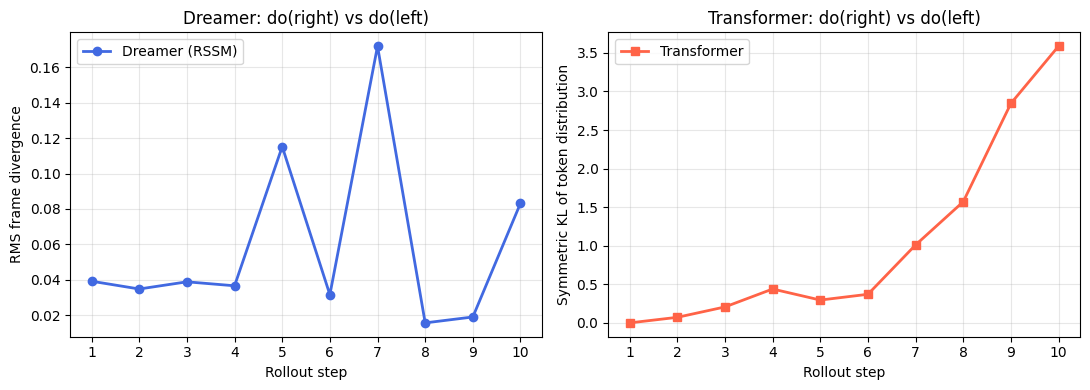

In [6]:
def frame_divergence(frames_a, frames_b):
    return [(fa - fb).pow(2).mean().sqrt().item() for fa, fb in zip(frames_a, frames_b)]


def token_kl_divergence(probs_a, probs_b, eps=1e-8):
    """Symmetric KL between two per-step categorical token distributions."""
    pa = probs_a.clamp_min(eps)
    pb = probs_b.clamp_min(eps)
    kl = (pa * (pa / pb).log()).sum(-1) + (pb * (pb / pa).log()).sum(-1)
    return kl.cpu().tolist()


d_div = frame_divergence(d_frm_r, d_frm_l)       # Dreamer: pixel RMS
t_div = token_kl_divergence(t_prob_r, t_prob_l)  # Transformer: token KL
steps = list(range(1, ROLLOUT_LEN + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(steps, d_div, 'o-', color='royalblue', linewidth=2, label='Dreamer (RSSM)')
ax1.set_xlabel('Rollout step')
ax1.set_ylabel('RMS frame divergence')
ax1.set_title('Dreamer: do(right) vs do(left)')
ax1.set_xticks(steps)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(steps, t_div, 's-', color='tomato', linewidth=2, label='Transformer')
ax2.set_xlabel('Rollout step')
ax2.set_ylabel('Symmetric KL of token distribution')
ax2.set_title('Transformer: do(right) vs do(left)')
ax2.set_xticks(steps)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Rung Three: Counterfactual Rollouts by Abduction

The interventional test starts from a blank latent state. The counterfactual question is stronger: take a trajectory that *actually* happened, and ask what would have happened at some step had the agent chosen the other action, while keeping the rest of the world as it was. Pearl's recipe has three moves: abduction, then action, then prediction.

Abduction infers the latent state that actually produced the observed trajectory. The RSSM posterior does exactly this, so we run it forward on the real frames and actions up to a branch point. Action substitutes a different choice at that branch point. Prediction rolls the prior forward from the abducted state under the new action. The factual and counterfactual branches share the same past and differ only in the intervened action, which is what makes the comparison a clean counterfactual.

In [7]:
@torch.no_grad()
def abduct_state(obs_seq, act_seq, branch_t):
    """Run the RSSM posterior along the real trajectory up to branch_t, returning (h, s)."""
    h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
    mu0, _ = encoder(obs_seq[0:1].to(DEVICE))
    s = mu0
    for t in range(branch_t):
        mu_t, _ = encoder(obs_seq[t:t+1].to(DEVICE))
        a_t = act_seq[t:t+1].to(DEVICE)
        s, h = rssm.posterior_step(h, a_t, mu_t)
    return h, s


@torch.no_grad()
def counterfactual_branch(h, action_seq):
    """Predict the prior rollout from an abducted state under a chosen action sequence."""
    frames = []
    for a in action_seq:
        a_t = torch.tensor([a], device=DEVICE)
        s, h = rssm.prior_step(h, a_t)
        frames.append(decoder(torch.cat([h, s], dim=-1)).squeeze(0))
    return torch.stack(frames)


traj_i, BRANCH = 0, 4
obs_seq = eval_obs[traj_i]
act_seq = eval_act[traj_i]

h_b, s_b = abduct_state(obs_seq, act_seq, BRANCH)            # abduction
factual_actions = act_seq[BRANCH:ROLLOUT_LEN].tolist()       # what actually happened next
cf_actions      = [1 - a for a in factual_actions]           # the action, flipped

factual_frames = counterfactual_branch(h_b, factual_actions)
cf_frames      = counterfactual_branch(h_b, cf_actions)

print(f'Abducted state at step {BRANCH}; factual vs counterfactual branches rolled forward.')

Abducted state at step 4; factual vs counterfactual branches rolled forward.


Once the two branches are rolled out, display them side by side. The shared prefix is identical by construction, so any visible difference downstream is the causal effect of the flipped action.

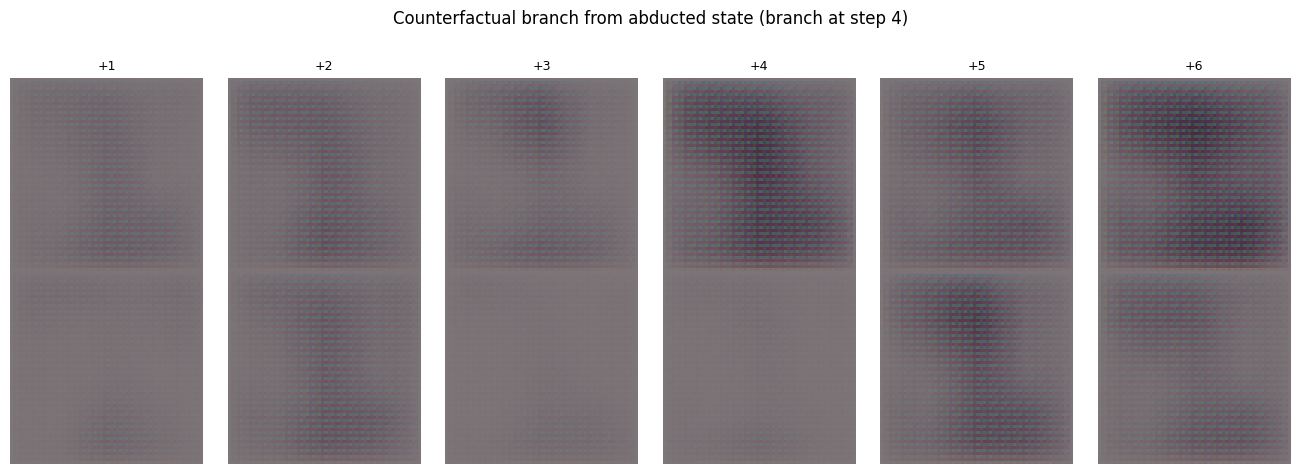

In [8]:
n_show = len(factual_actions)
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.6))
for col in range(n_show):
    axes[0, col].imshow(np.clip(factual_frames[col].cpu().permute(1, 2, 0).numpy(), 0, 1))
    axes[1, col].imshow(np.clip(cf_frames[col].cpu().permute(1, 2, 0).numpy(), 0, 1))
    for row in range(2):
        axes[row, col].axis('off')
    axes[0, col].set_title(f'+{col + 1}', fontsize=9)
axes[0, 0].set_ylabel('Factual', fontsize=10)
axes[1, 0].set_ylabel('Counterfactual', fontsize=10)
fig.suptitle(f'Counterfactual branch from abducted state (branch at step {BRANCH})', y=1.02)
plt.tight_layout()
plt.show()

## 6. Making a Model Genuinely Action-Causal

The rollouts above probe models that were trained for prediction, not for causal fidelity, so a model can score well on reconstruction while quietly ignoring the action. The World-Action Model line of work fixes this with an inverse-dynamics regularizer: alongside the forward prediction loss, a small head must recover the action `a_t` from the latent transition between `s_t` and `s_{t+1}`. If the action cannot be read back out of the transition, the dynamics are not really conditioned on it. Adding this loss forces the latent transition to carry the action's effect.

We train two compact world models on the synthetic environment, one with the inverse-dynamics term and one without, then compare how action-sensitive each becomes.

In [9]:
def make_training_set(n_traj=300, horizon=SEQ_LEN, base_seed=0):
    obs_list, act_list = [], []
    for i in range(n_traj):
        env = SyntheticEnv(seed=base_seed + i)
        obs = env.reset()
        traj_obs, traj_act = [obs], []
        rng = np.random.RandomState(base_seed + i + 50000)
        for _ in range(horizon):
            a = rng.randint(0, N_ACTIONS)
            nxt, _, _ = env.step(a)
            traj_act.append(a)
            traj_obs.append(nxt)
        obs_list.append(traj_obs[:horizon])
        act_list.append(traj_act)
    return (torch.tensor(np.array(obs_list), dtype=torch.float32),
            torch.tensor(np.array(act_list), dtype=torch.long))


class CompactWM(nn.Module):
    """Small action-conditioned latent dynamics model with an inverse-dynamics head."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, n_actions=N_ACTIONS):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Flatten(), nn.Linear(256 * 4 * 4, latent_dim),
        )
        self.a_embed = nn.Embedding(n_actions, latent_dim)
        self.fwd = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        # Inverse-dynamics head: recover the action from (s_t, s_{t+1})
        self.inv = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def encode(self, x):
        return self.enc(x)

    def forward_dynamics(self, s, a):
        return self.fwd(torch.cat([s, self.a_embed(a)], dim=-1))

    def inverse_dynamics(self, s, s_next):
        return self.inv(torch.cat([s, s_next], dim=-1))


def train_compact_wm(use_inverse, epochs=8, lam=1.0, seed=0):
    torch.manual_seed(seed)
    model = CompactWM().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    obs, act = make_training_set()
    N, T = act.shape
    for _ in range(epochs):
        perm = torch.randperm(N)
        for i in range(0, N, 32):
            idx = perm[i:i + 32]
            o = obs[idx].to(DEVICE)                       # (B, T, 3, 64, 64)
            a = act[idx].to(DEVICE)                       # (B, T)
            B = o.shape[0]
            s = model.encode(o.reshape(B * T, 3, 64, 64)).reshape(B, T, -1)
            s_t, s_next = s[:, :-1], s[:, 1:]
            a_t = a[:, :-1]
            pred_next = model.forward_dynamics(s_t.reshape(-1, LATENT_DIM), a_t.reshape(-1))
            fwd_loss = F.mse_loss(pred_next, s_next.reshape(-1, LATENT_DIM).detach())
            loss = fwd_loss
            if use_inverse:
                a_logits = model.inverse_dynamics(s_t.reshape(-1, LATENT_DIM), s_next.reshape(-1, LATENT_DIM))
                loss = loss + lam * F.cross_entropy(a_logits, a_t.reshape(-1))
            opt.zero_grad()
            loss.backward()
            opt.step()
    model.eval()
    return model


print('Training action-regularized world model...')
causal_wm   = train_compact_wm(use_inverse=True)
print('Training baseline world model (no inverse-dynamics term)...')
baseline_wm = train_compact_wm(use_inverse=False)
print('Both compact models trained.')

Training action-regularized world model...
Training baseline world model (no inverse-dynamics term)...
Both compact models trained.


## 7. Action-Influence Metric

To put a number on action-conditioning, measure how much the predicted next latent changes when only the action is flipped, averaged over held-out states. A model that respects the action produces a large influence score; an action-collapsed model produces a score near zero. We report it for the action-regularized model, the baseline, and the loaded Dreamer RSSM.

Action influence (higher = more action-conditioned):
  Action-regularized WM : 4.2859
  Baseline WM           : 1.6977
  Dreamer RSSM (P03)    : 1.9519


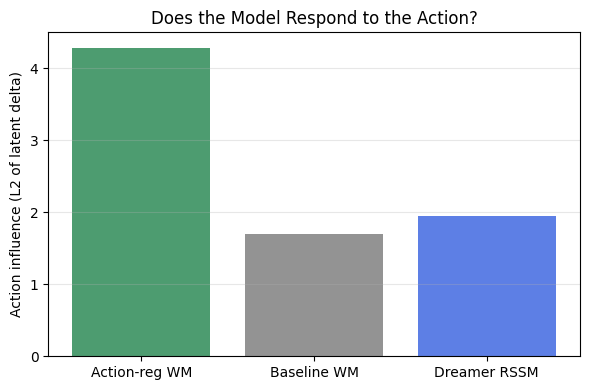

In [10]:
@torch.no_grad()
def action_influence_compact(model, obs, n=256):
    s = model.encode(obs[:n].to(DEVICE))
    a0 = torch.zeros(s.shape[0], dtype=torch.long, device=DEVICE)
    a1 = torch.ones_like(a0)
    s0 = model.forward_dynamics(s, a0)
    s1 = model.forward_dynamics(s, a1)
    return (s0 - s1).pow(2).sum(-1).sqrt().mean().item()


@torch.no_grad()
def action_influence_rssm(obs, n=256):
    h = torch.zeros(min(n, obs.shape[0]), rssm.hidden_dim, device=DEVICE)
    a0 = torch.zeros(h.shape[0], dtype=torch.long, device=DEVICE)
    a1 = torch.ones_like(a0)
    _, h0 = rssm.prior_step(h, a0)
    _, h1 = rssm.prior_step(h, a1)
    return (h0 - h1).pow(2).sum(-1).sqrt().mean().item()


flat_obs = eval_obs.reshape(-1, 3, 64, 64)
infl_causal   = action_influence_compact(causal_wm, flat_obs)
infl_baseline = action_influence_compact(baseline_wm, flat_obs)
infl_rssm     = action_influence_rssm(flat_obs)

print(f'Action influence (higher = more action-conditioned):')
print(f'  Action-regularized WM : {infl_causal:.4f}')
print(f'  Baseline WM           : {infl_baseline:.4f}')
print(f'  Dreamer RSSM (P03)    : {infl_rssm:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['Action-reg WM', 'Baseline WM', 'Dreamer RSSM']
vals  = [infl_causal, infl_baseline, infl_rssm]
ax.bar(names, vals, color=['seagreen', 'gray', 'royalblue'], alpha=0.85)
ax.set_ylabel('Action influence (L2 of latent delta)')
ax.set_title('Does the Model Respond to the Action?')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The scalar above is a one-step summary. To see the effect accumulate, roll the action-regularized model and the baseline forward from the same encoded state under `do(right)` against `do(left)`, and plot how far the predicted latents separate at each step. The regularized model should fan out while the baseline stays flat, giving the interventional plot the clear contrast the loaded checkpoints could not.

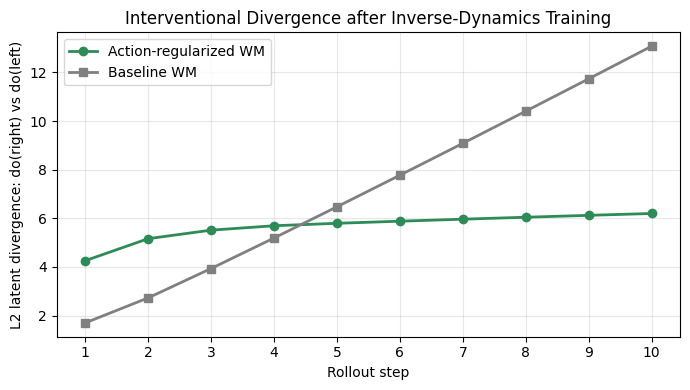

In [11]:
@torch.no_grad()
def compact_intervention_divergence(model, seed_obs, steps=ROLLOUT_LEN):
    """Roll a CompactWM forward under do(right) vs do(left) from one encoded state."""
    s = model.encode(seed_obs.unsqueeze(0).to(DEVICE))
    s_r = s_l = s
    div = []
    for _ in range(steps):
        a_r = torch.zeros(1, dtype=torch.long, device=DEVICE)
        a_l = torch.ones(1, dtype=torch.long, device=DEVICE)
        s_r = model.forward_dynamics(s_r, a_r)
        s_l = model.forward_dynamics(s_l, a_l)
        div.append((s_r - s_l).pow(2).sum(-1).sqrt().item())
    return div


causal_div   = compact_intervention_divergence(causal_wm, seed)
baseline_div = compact_intervention_divergence(baseline_wm, seed)
steps = list(range(1, ROLLOUT_LEN + 1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps, causal_div, 'o-', color='seagreen', linewidth=2, label='Action-regularized WM')
ax.plot(steps, baseline_div, 's-', color='gray', linewidth=2, label='Baseline WM')
ax.set_xlabel('Rollout step')
ax.set_ylabel('L2 latent divergence: do(right) vs do(left)')
ax.set_title('Interventional Divergence after Inverse-Dynamics Training')
ax.set_xticks(steps)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save Checkpoint and Summary

Save the action-regularized model for reuse and record the headline numbers.

In [12]:
torch.save({
    'causal_wm': causal_wm.state_dict(),
    'action_influence': {
        'causal': infl_causal,
        'baseline': infl_baseline,
        'dreamer_rssm': infl_rssm,
    },
}, CAUSAL_CKPT)
print(f'Saved action-regularized world model to {CAUSAL_CKPT}')

print('\n--- P06 Summary ---')
print(f'  Dreamer / Transformer checkpoints loaded : {dreamer_loaded} / {trans_loaded}')
print(f'  Dreamer interventional divergence (step 10, RMS px) : {d_div[-1]:.4f}')
print(f'  Transformer interventional divergence (step 10, token KL) : {t_div[-1]:.4f}')
print(f'  Action influence (regularized)           : {infl_causal:.4f}')
print(f'  Action influence (baseline)              : {infl_baseline:.4f}')
print('  A large gap between the two confirms the inverse-dynamics term induces action-conditioning.')

Saved action-regularized world model to causal_wm.pt

--- P06 Summary ---
  Dreamer / Transformer checkpoints loaded : True / True
  Dreamer interventional divergence (step 10, RMS px) : 0.0832
  Transformer interventional divergence (step 10, token KL) : 3.5875
  Action influence (regularized)           : 4.2859
  Action influence (baseline)              : 1.6977
  A large gap between the two confirms the inverse-dynamics term induces action-conditioning.


The lesson of P06 is that accuracy and causal fidelity are different axes. A world model can reconstruct frames well, the question P05 measured, while still failing to encode the effect of the action, the question measured here. Counterfactual rollouts expose that gap directly, and the inverse-dynamics regularizer is one concrete way to close it. This is the sense in which the interview framing of structured compression matters: a useful world model compresses observations into variables that respond to interventions, not just statistics that reproduce the training distribution.